# Weather EDA — SFO NOAA Hourly Data

This notebook explores the cleaned hourly SFO NOAA weather data and uses the following workflow:

1. validate and order the time-series data
2. create chronological train, validate, and test splits before EDA
3. perform EDA on the training split only so validation and test observations remain unseen.

In [11]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Theme configurations
sns.set_theme(style="darkgrid")
plt.style.use("dark_background")
sns.set_palette("viridis")

plt.rcParams.update({
    "figure.facecolor": "#191a1c",
    "axes.facecolor": "#191a1c",
    "savefig.facecolor": "#191a1c",
    "grid.color": "#252628",
})

RANDOM_STATE = 207 # DATASCI
PRIMARY_COLOR = "teal"
SPLIT_COLORS = {
    "train": "#440154",
    "validation": "#31688e",
    "test": "#21918c",
}

### Load the cleaned hourly data

In [12]:
REPO_ROOT = Path.cwd().parents[1]
CLEANED_PARQUET_PATH = REPO_ROOT / "Data_Preprocessing" / "santi" / "data" / "cleaned" / "sfo_noaa_cleaned.parquet"

required_columns = {
    "DATE",
    "Year",
    "Month",
    "Day",
    "Hour",
    "Minute",
    "LATITUDE",
    "LONGITUDE",
    "ELEVATION",
    "temperature",
    "dew_point_temperature",
    "relative_humidity",
    "visibility",
    "wind_speed",
    "wind_direction",
    "sea_level_pressure",
    "station_level_pressure",
    "wet_bulb_temperature",
    "ceiling_height",
    "altimeter",
    "sky_condition_baseht",
    "sky_cover_summation_baseht_1",
    "precipitation",
}

weather_df = pd.read_parquet(CLEANED_PARQUET_PATH)
missing_required_columns = sorted(required_columns.difference(weather_df.columns))

weather_df["DATE"] = pd.to_datetime(weather_df["DATE"], errors="raise")
weather_df = weather_df.sort_values("DATE").reset_index(drop=True)

print(f"Loaded: {CLEANED_PARQUET_PATH}")
print(f"Shape: {weather_df.shape}")
print(f"Date range: {weather_df['DATE'].min()} to {weather_df['DATE'].max()}")
display(weather_df.head())

Loaded: c:\Users\smeri\OneDrive\Desktop\MIDS Coursework\207-Summer26-FinalProject-MLModel\Data_Preprocessing\santi\data\cleaned\sfo_noaa_cleaned.parquet
Shape: (38732, 23)
Date range: 2022-01-01 00:56:00 to 2026-06-09 16:56:00


,DATE,Year,Month,Day,Hour,Minute,LATITUDE,LONGITUDE,ELEVATION,temperature,...,wind_speed,wind_direction,sea_level_pressure,station_level_pressure,wet_bulb_temperature,ceiling_height,altimeter,sky_condition_baseht,sky_cover_summation_baseht_1,precipitation
0,2022-01-01 00:56:00,2022,1,1,0,56,37.6197,-122.3656,3.0,10.6,...,7.2,300.0,1012.8,1012.3,7.9,22000.0,1012.9,610.0,610.0,0.0
1,2022-01-01 01:56:00,2022,1,1,1,56,37.6197,-122.3656,3.0,10.0,...,5.1,300.0,1013.3,1012.6,7.4,22000.0,1013.2,579.0,579.0,0.0
2,2022-01-01 02:56:00,2022,1,1,2,56,37.6197,-122.3656,3.0,9.4,...,5.1,290.0,1014.0,1013.6,7.1,22000.0,1014.2,NaN,NaN,0.0
3,2022-01-01 03:56:00,2022,1,1,3,56,37.6197,-122.3656,3.0,9.4,...,5.1,310.0,1014.6,1014.0,7.3,22000.0,1014.6,914.0,914.0,0.0
4,2022-01-01 04:56:00,2022,1,1,4,56,37.6197,-122.3656,3.0,8.9,...,2.6,330.0,1015.5,1015.0,7.1,22000.0,1015.6,NaN,NaN,0.0


### Investigating Time Gaps

In [13]:
timestamp_deltas = weather_df["DATE"].diff().dropna()
gaps_longer_than_hour = timestamp_deltas[timestamp_deltas > pd.Timedelta(hours=1)]
hourly_gap_count = len(gaps_longer_than_hour)

gap_distribution = (
    gaps_longer_than_hour.value_counts()
    .sort_index()
    .rename_axis("gap_length")
    .reset_index(name="gap_count")
)
gap_distribution["gap_hours"] = (
    gap_distribution["gap_length"] / pd.Timedelta(hours=1)
)

print(f"Gaps longer than one hour: {hourly_gap_count}")
display(gap_distribution)

Gaps longer than one hour: 53


,gap_length,gap_count,gap_hours
0,0 days 02:00:00,39,2.0
1,0 days 03:00:00,8,3.0
2,0 days 04:00:00,3,4.0
3,0 days 05:00:00,1,5.0
4,0 days 08:00:00,1,8.0
5,3 days 19:00:00,1,91.0


### Chronological train, validation, and test design

The final test period begins on January 1, 2025 and remains outside cross-validation. The train period contains 2022–2024. Within it, `TimeSeriesSplit` creates two windows splits with a holdout size equal to the number of observations in 2024. This makes the final split align with the following:

- **training:** 2022–2023
- **validation:** 2024
- **final test:** 2025 through July 2026.

In [14]:
VALIDATION_START = pd.Timestamp("2024-01-01")
TEST_START = pd.Timestamp("2025-01-01")

weather_df = weather_df.sort_values("DATE").reset_index(drop=True)

weather_train_df = weather_df[weather_df["DATE"] < VALIDATION_START].copy().reset_index(drop=True)
weather_validation_df = weather_df[(weather_df["DATE"] >= VALIDATION_START) & (weather_df["DATE"] < TEST_START)].copy().reset_index(drop=True)
weather_test_df = weather_df[weather_df["DATE"] >= TEST_START].copy().reset_index(drop=True)

splits = pd.DataFrame(
    {
        "splits": ["train", "validation", "test"],
        "rows": [
            weather_train_df.shape[0],
            weather_validation_df.shape[0],
            weather_test_df.shape[0]
        ],
        'start_date': [
            weather_train_df["DATE"].min(),
            weather_validation_df["DATE"].min(),
            weather_test_df["DATE"].min(),
        ],
        'end_date': [
            weather_train_df["DATE"].max(),
            weather_validation_df["DATE"].max(),
            weather_test_df["DATE"].max(),
        ],
    }
)

splits["percent_of_rows"] = round((splits["rows"] / weather_df.shape[0]) * 100, 2)  

display(splits)

,splits,rows,start_date,end_date,percent_of_rows
0,train,17514,2022-01-01 00:56:00,2023-12-31 23:56:00,45.22
1,validation,8771,2024-01-01 00:56:00,2024-12-31 23:56:00,22.65
2,test,12447,2025-01-01 00:56:00,2026-06-09 16:56:00,32.14


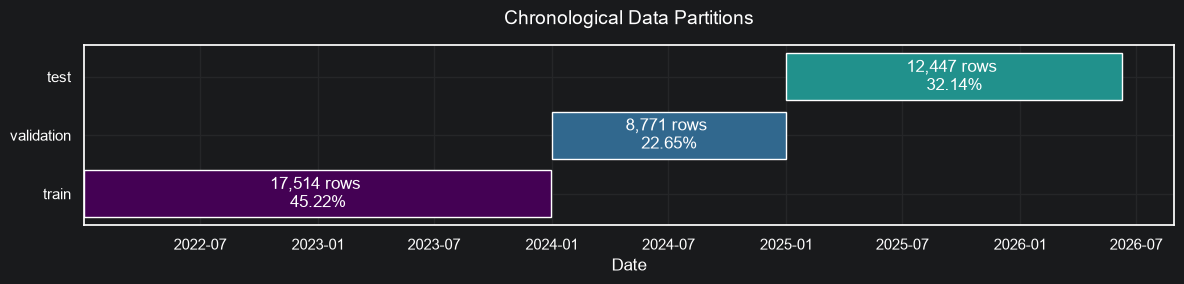

In [15]:
# Plot partitions
fig, ax = plt.subplots(figsize=(12, 3))

for row_num, row in splits.iterrows():
    start_date = row["start_date"]
    end_date = row["end_date"]
    ax.barh(
        row["splits"],
        width = (end_date - start_date).days,
        left = start_date,
        color=SPLIT_COLORS[row["splits"]],
    )
    ax.text(
        x=start_date + (end_date - start_date) / 2,
        y=row_num,
        s=f"{row['rows']:,} rows \n{row['percent_of_rows']}%",
        va="center",
        ha="center",
        color="white",
        fontsize=12,
    )

plt.xlabel("Date")
plt.title("Chronological Data Partitions", fontsize=14, pad=15)
plt.tight_layout()
plt.show()

### EDA on Training Set - Feature Columns

In [16]:
station_columns = ["LATITUDE", "LONGITUDE", "ELEVATION"]
calendar_columns = ["Year", "Month", "Day", "Hour", "Minute"]
weather_feature_columns = [
    "temperature",
    "dew_point_temperature",
    "relative_humidity",
    "visibility",
    "wind_speed",
    "wind_direction",
    "sea_level_pressure",
    "station_level_pressure",
    "wet_bulb_temperature",
    "ceiling_height",
    "altimeter",
    "sky_condition_baseht",
    "sky_cover_summation_baseht_1",
    "precipitation",
]

missing_summary = pd.DataFrame({
    "column_name": weather_train_df[weather_feature_columns].columns,
    "dtype": weather_train_df[weather_feature_columns].dtypes.values,
    "nulls_count": weather_train_df[weather_feature_columns].isna().sum().values,
    "nulls_percent": (weather_train_df[weather_feature_columns].isna().mean().values * 100).round(3),
    "unique_values": weather_train_df[weather_feature_columns].nunique().values
})

display(missing_summary)

,column_name,dtype,nulls_count,nulls_percent,unique_values
0,temperature,float64,2,0.011,65
1,dew_point_temperature,float64,2,0.011,55
2,relative_humidity,float64,2,0.011,80
3,visibility,float64,0,0.000,19
4,wind_speed,float64,2,0.011,39
5,wind_direction,float64,1817,10.375,36
6,sea_level_pressure,float64,9,0.051,333
7,station_level_pressure,float64,113,0.645,112
8,wet_bulb_temperature,float64,115,0.657,212
9,ceiling_height,float64,0,0.000,76


In [17]:
weather_statistics = (
    weather_train_df[weather_feature_columns]
    .describe()
    .transpose()
    .reset_index()
    .rename(columns={"index": "column_name"})
)

display(weather_statistics)

,column_name,count,mean,std,min,25%,50%,75%,max
0,temperature,17512.0,14.550297,4.193429,2.2,11.700,14.400,17.200,36.700
1,dew_point_temperature,17512.0,9.076376,3.841569,-8.9,6.700,9.400,12.200,20.000
2,relative_humidity,17512.0,71.553164,14.015236,15.0,63.000,74.000,83.000,100.000
3,visibility,17514.0,15.643992,1.938649,0.0,16.093,16.093,16.093,16.093
4,wind_speed,17512.0,4.691863,3.184791,0.0,2.100,4.100,6.700,22.100
5,wind_direction,15697.0,240.389246,84.648988,10.0,200.000,280.000,300.000,360.000
6,sea_level_pressure,17505.0,1016.661205,5.061710,985.3,1013.300,1016.100,1019.900,1031.500
7,station_level_pressure,17401.0,1016.143561,5.074948,984.9,1012.900,1015.700,1019.400,1030.900
8,wet_bulb_temperature,17399.0,11.665504,3.332567,0.1,9.200,11.800,14.100,23.200
9,ceiling_height,17514.0,14269.281603,9674.229829,61.0,2438.000,22000.000,22000.000,22000.000


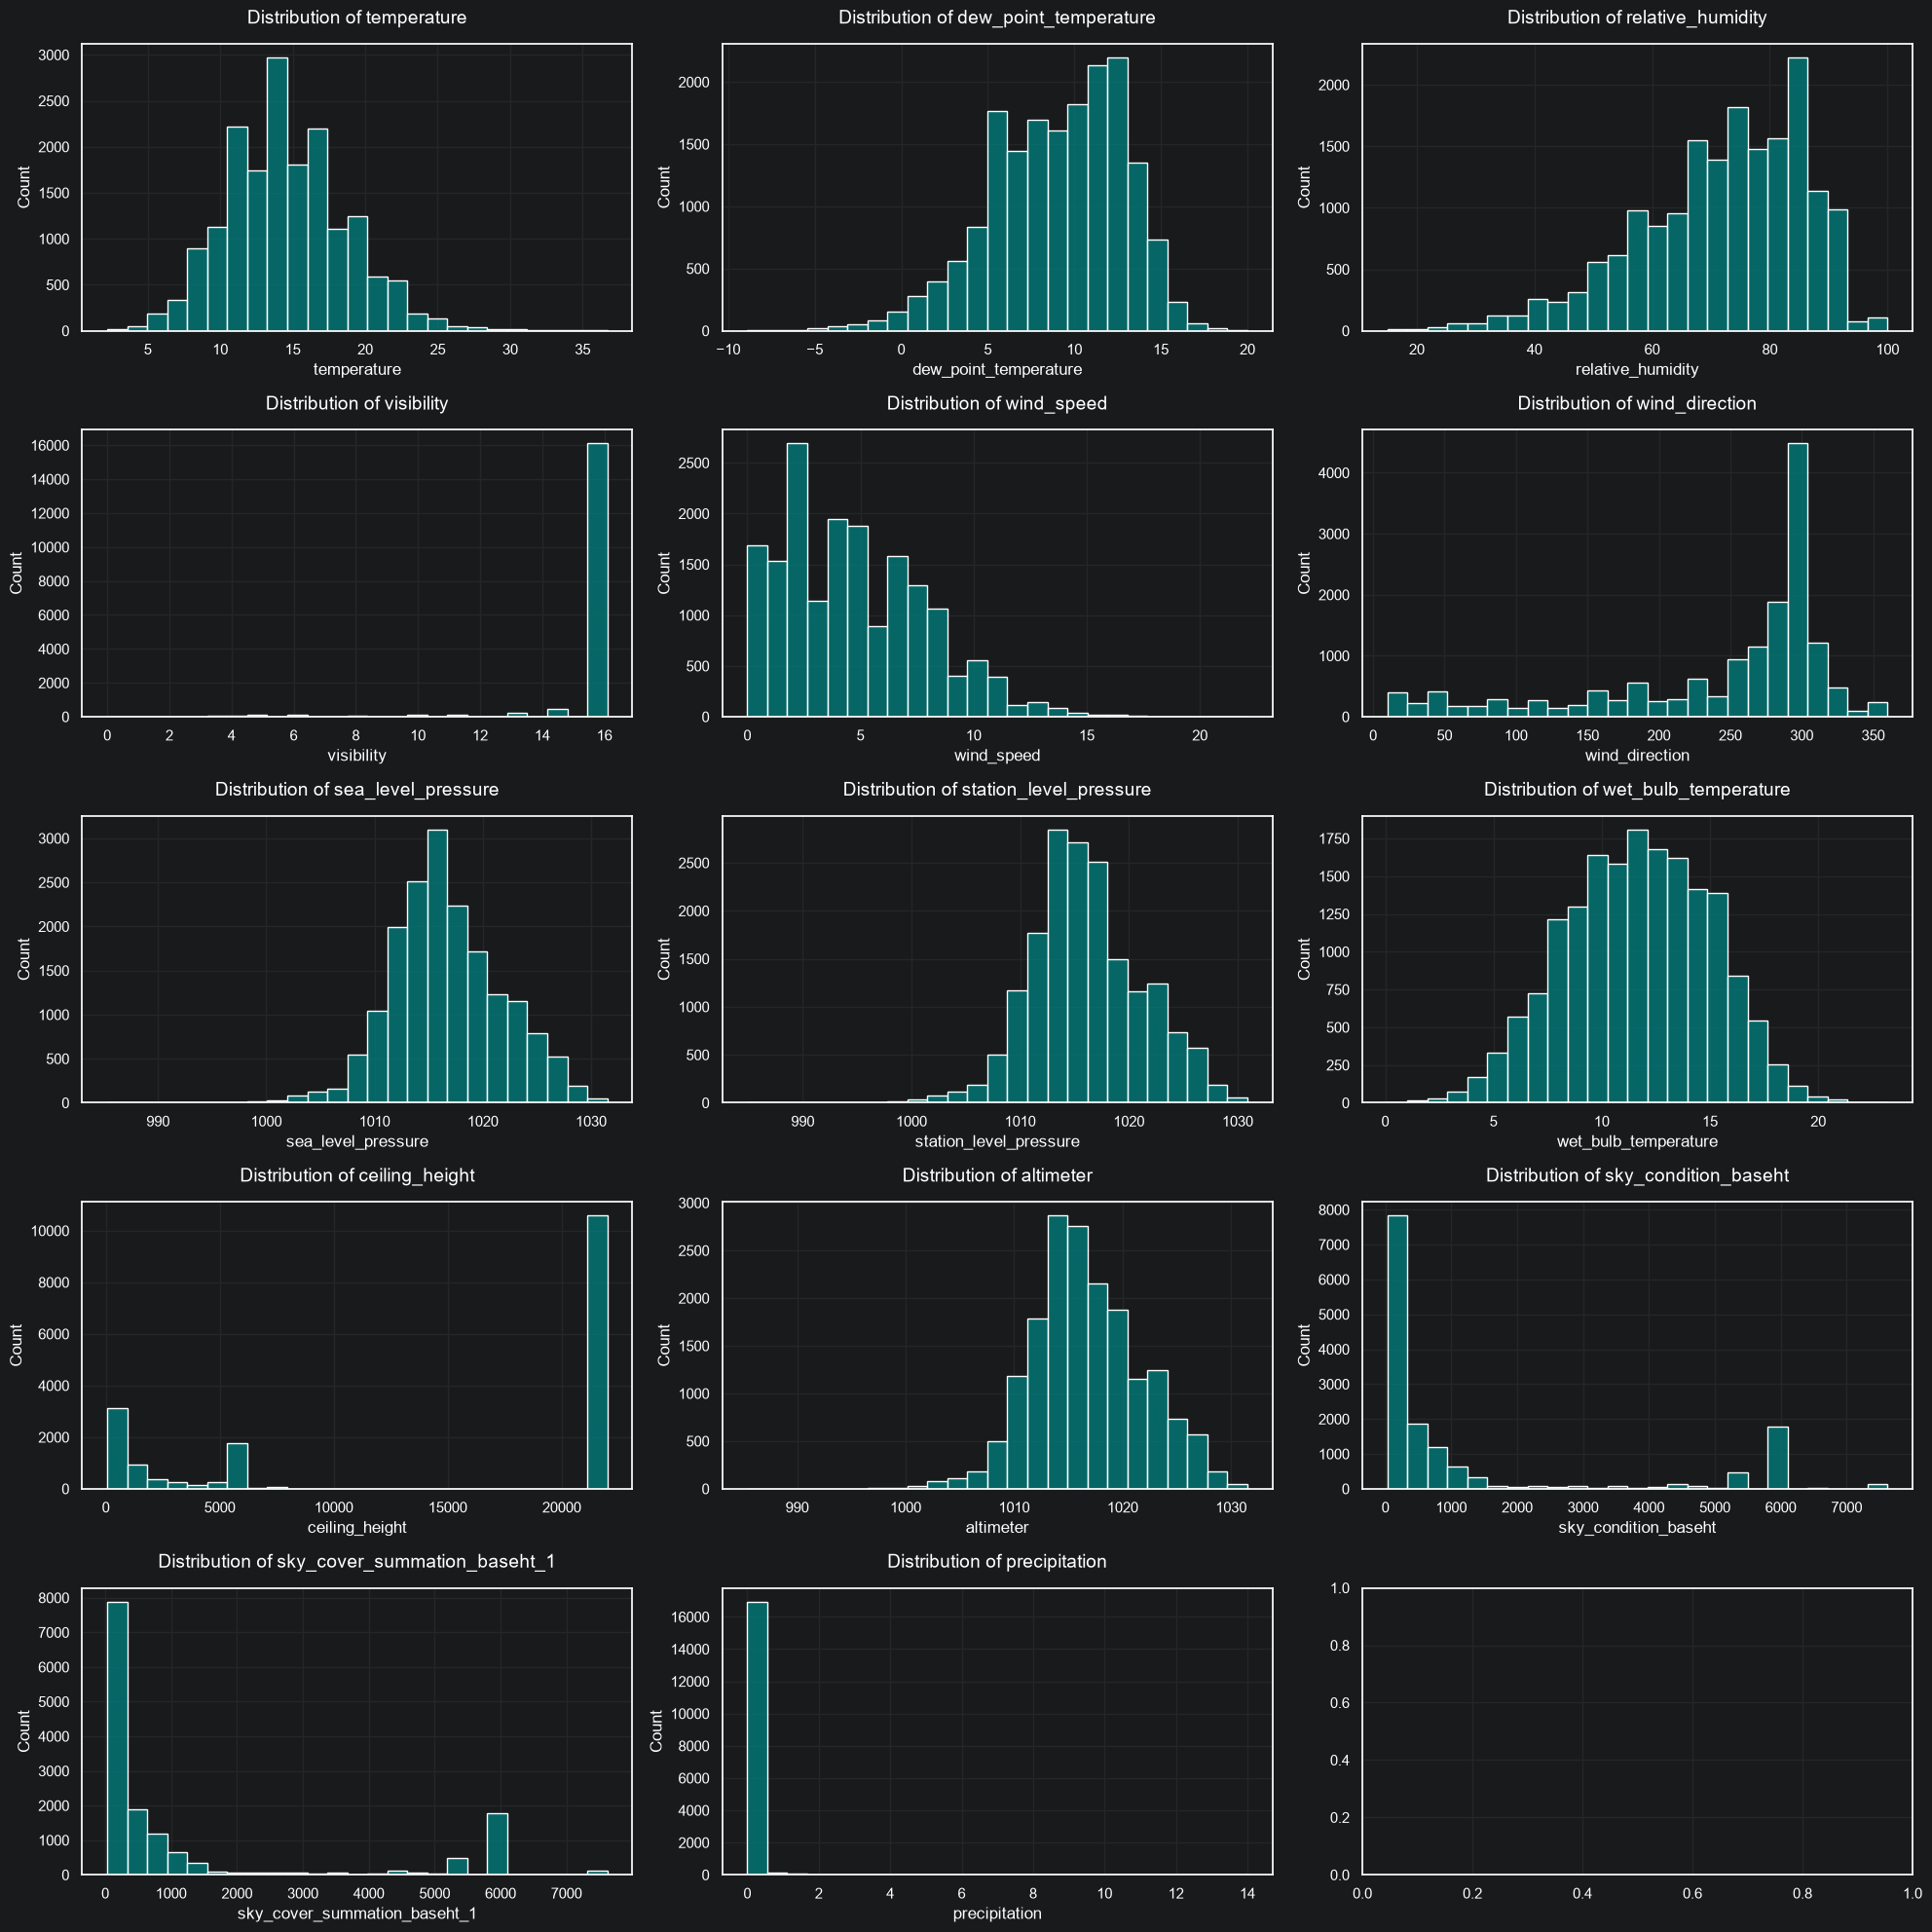

In [18]:
distribution_columns = [
    "temperature",
    "dew_point_temperature",
    "relative_humidity",
    "visibility",
    "wind_speed",
    "wind_direction",
    "sea_level_pressure",
    "station_level_pressure",
    "wet_bulb_temperature",
    "ceiling_height",
    "altimeter",
    "sky_condition_baseht",
    "sky_cover_summation_baseht_1",
    "precipitation"
]

fig, axes = plt.subplots(nrows=5, ncols=3, figsize=(20, 20))
axes = axes.flatten()

for i, column in enumerate(distribution_columns):
    sns.histplot(
        data=weather_train_df,
        x=column,
        bins=25,
        ax=axes[i],
        color=PRIMARY_COLOR,
        edgecolor="white",
    )
    axes[i].set_title(f"Distribution of {column}", fontsize=14, pad=15)
    axes[i].set_xlabel(column)
    axes[i].set_ylabel("Count")

plt.tight_layout()
plt.show()

### Exploring Precipitation

In [19]:
precipitation = weather_train_df["precipitation"]
precipitation_group = pd.Series(
    np.select(
        [precipitation.isna(), precipitation.eq(0), precipitation.gt(0)],
        ["missing", "zero", "positive"],
        default="other",
    ),
    index=weather_train_df.index,
    name="precipitation_group",
)

precipitation_order = ["missing", "zero", "positive", "other"]
precipitation_summary = (
    precipitation_group.value_counts()
    .reindex(precipitation_order, fill_value=0)
    .rename_axis("precipitation_group")
    .reset_index(name="rows")
)
precipitation_summary = precipitation_summary.loc[precipitation_summary["rows"] > 0]
precipitation_summary["percent"] = (
    precipitation_summary["rows"] / len(weather_train_df) * 100
).round(2)

positive_precipitation = precipitation.loc[precipitation.gt(0)]

display(precipitation_summary)

,precipitation_group,rows,percent
0,missing,195,1.11
1,zero,16676,95.22
2,positive,643,3.67


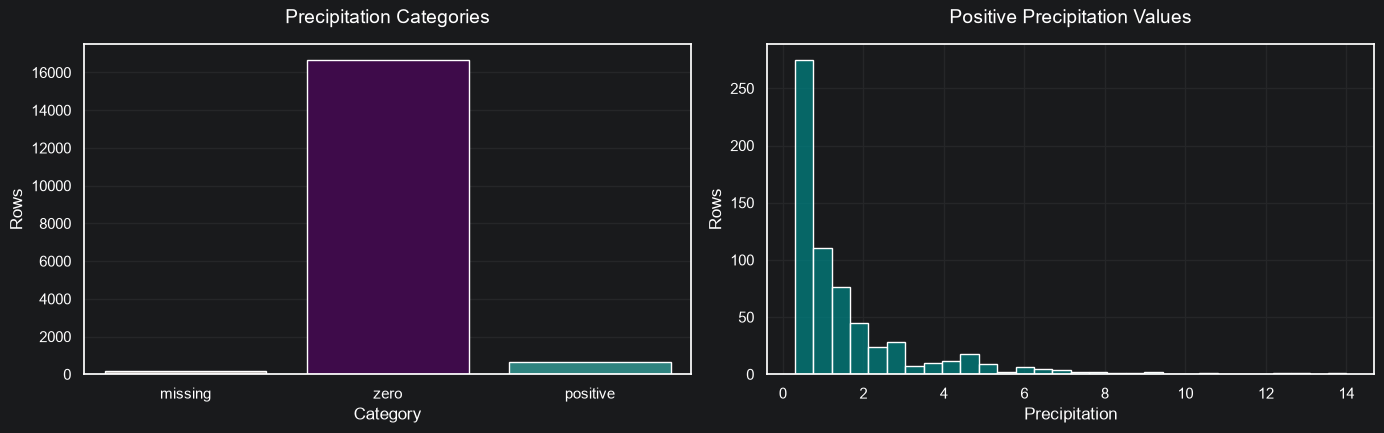

In [20]:
fig, axes = plt.subplots(ncols=2, figsize=(14, 4.5))
sns.barplot(
    data=precipitation_summary,
    x="precipitation_group",
    y="rows",
    hue="precipitation_group",
    palette={"missing": "#bab0ac", "zero": "#440154", "positive": "#21918c", "other": "#fde725"},
    legend=False,
    ax=axes[0],
)
axes[0].set_title("Precipitation Categories", fontsize=14, pad=15)
axes[0].set_xlabel("Category")
axes[0].set_ylabel("Rows")

sns.histplot(
    positive_precipitation,
    bins=30,
    color=PRIMARY_COLOR,
    edgecolor="white",
    ax=axes[1],
)
axes[1].set_title("Positive Precipitation Values", fontsize=14, pad=15)
axes[1].set_xlabel("Precipitation")
axes[1].set_ylabel("Rows")

plt.tight_layout()
plt.show()

Comment: There is clear imbalance when comparing missing and non positive precipitation values. Given that zero precipitation makes up more than 95% of the set and the distribution is right skewed for positive values, we may find little value in keeping precipitation as a feature. 

### Seasonal and hourly patterns

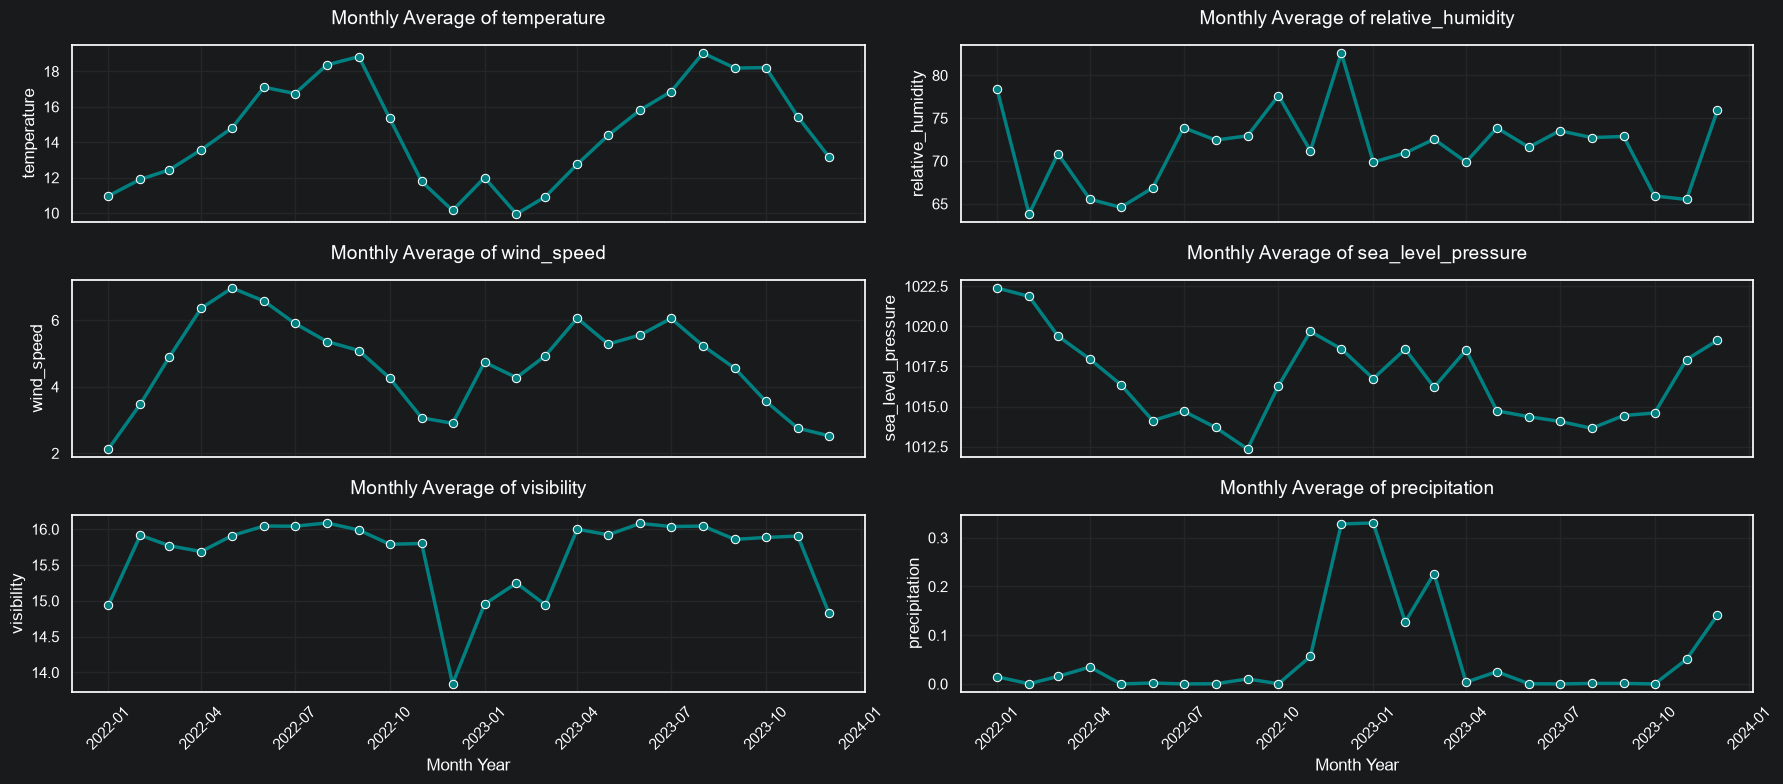

In [21]:
weather_train_df2 = weather_train_df.copy()
weather_train_df2["Month"] = weather_train_df2["DATE"].dt.month
weather_train_df2["Hour"] = weather_train_df2["DATE"].dt.hour
weather_train_df2["Month Year"] = weather_train_df2["DATE"].dt.to_period("M").dt.to_timestamp()

monthly_columns = ["temperature", "relative_humidity", "wind_speed", "sea_level_pressure", "visibility", "precipitation"]

monthly_weather = (weather_train_df2.groupby("Month Year")[monthly_columns].mean().reset_index())

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(18, 8), sharex=True)
axes = axes.flatten()

for i, column in enumerate(monthly_columns):
    sns.lineplot(
        data=monthly_weather,
        x="Month Year",
        y=column,
        marker="o",
        ax=axes[i],
        color=PRIMARY_COLOR,
        linewidth=2.5,
    )
    axes[i].set_title(f"Monthly Average of {column}", fontsize=14, pad=15)
    axes[i].set_xlabel("Month Year")
    axes[i].set_ylabel(column)
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### Average by Month and Hour

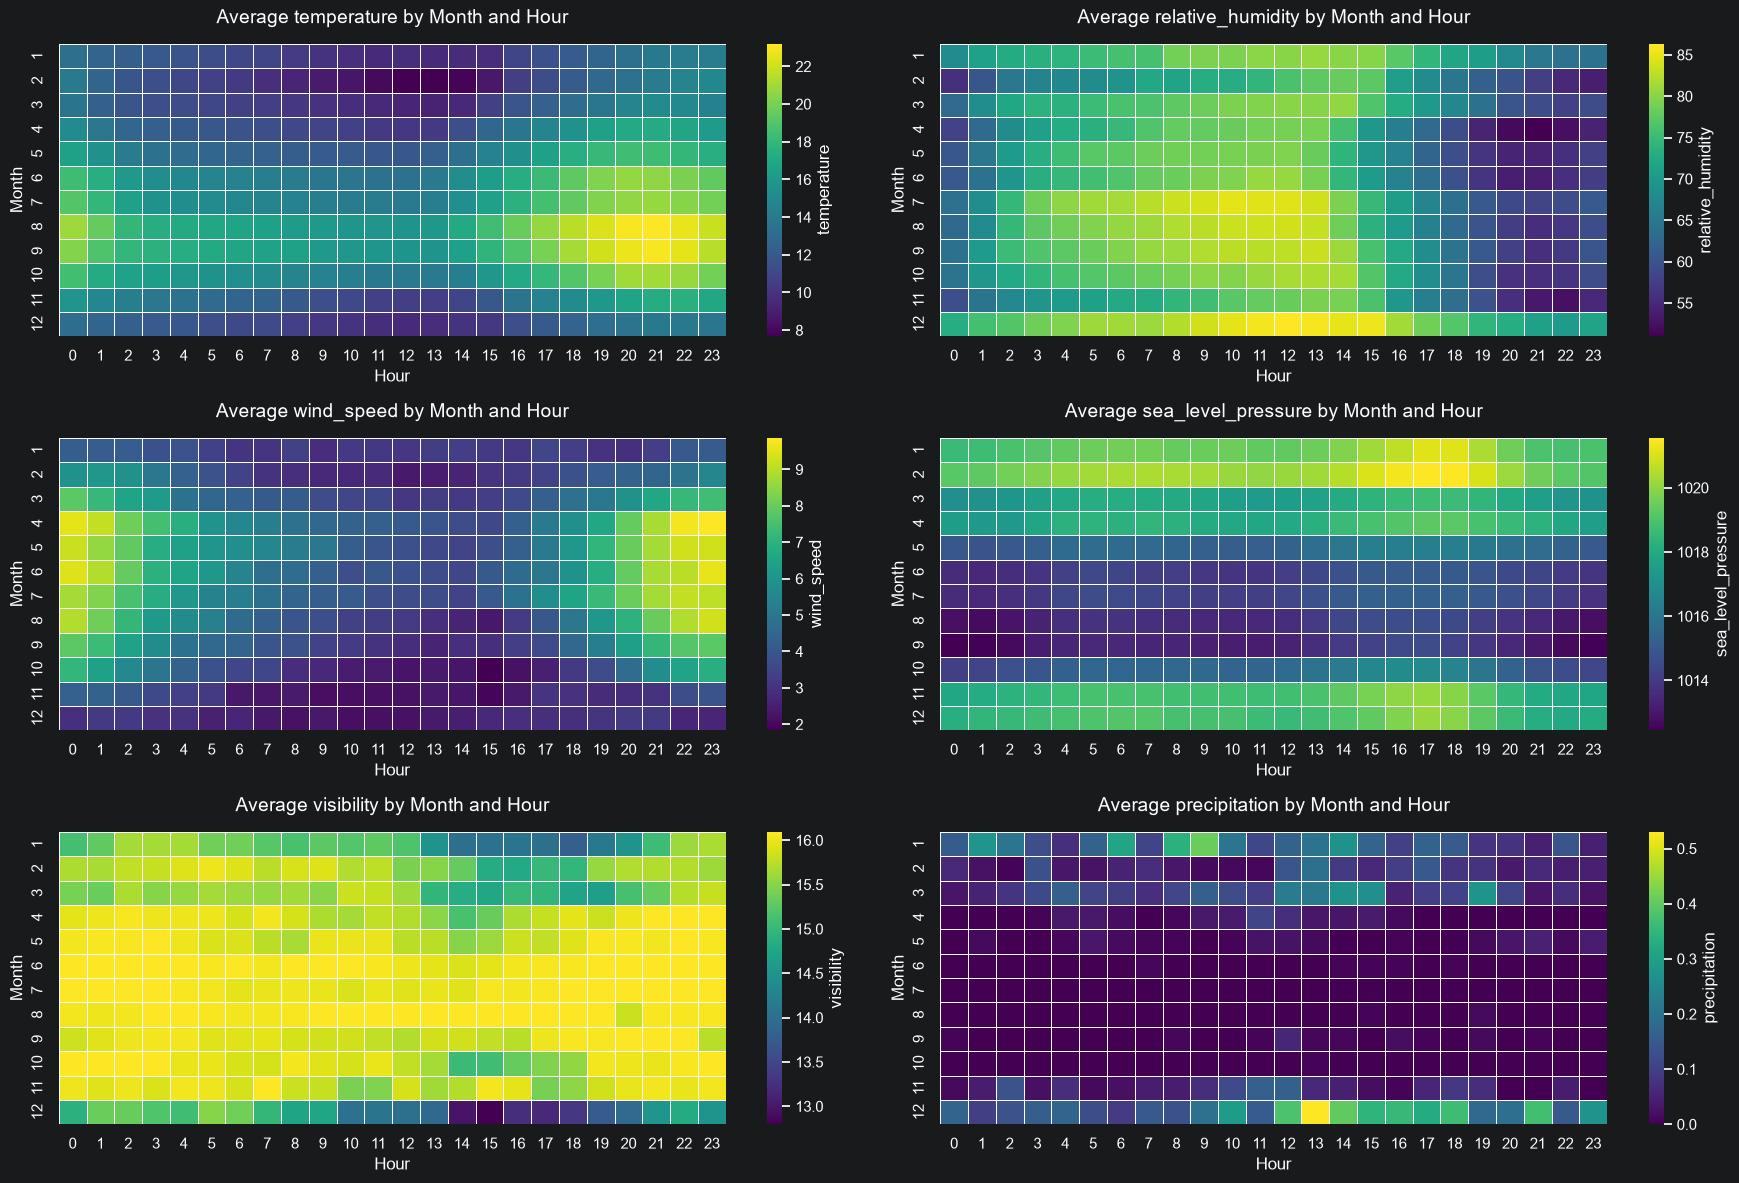

In [22]:
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(18, 12))
axes = axes.flatten()

for index, column in enumerate(monthly_columns):
    hourly_monthly = weather_train_df2.pivot_table(
        index="Month",
        columns="Hour",
        values=column,
        aggfunc="mean",
    )
    sns.heatmap(
        hourly_monthly,
        cmap="viridis",
        linewidths=0.5,
        cbar_kws={"label": column},
        ax=axes[index],
    )
    axes[index].set_title(f"Average {column} by Month and Hour", fontsize=14, pad=15)
    axes[index].set_xlabel("Hour")
    axes[index].set_ylabel("Month")

plt.tight_layout()
plt.show()

### Correlation Map

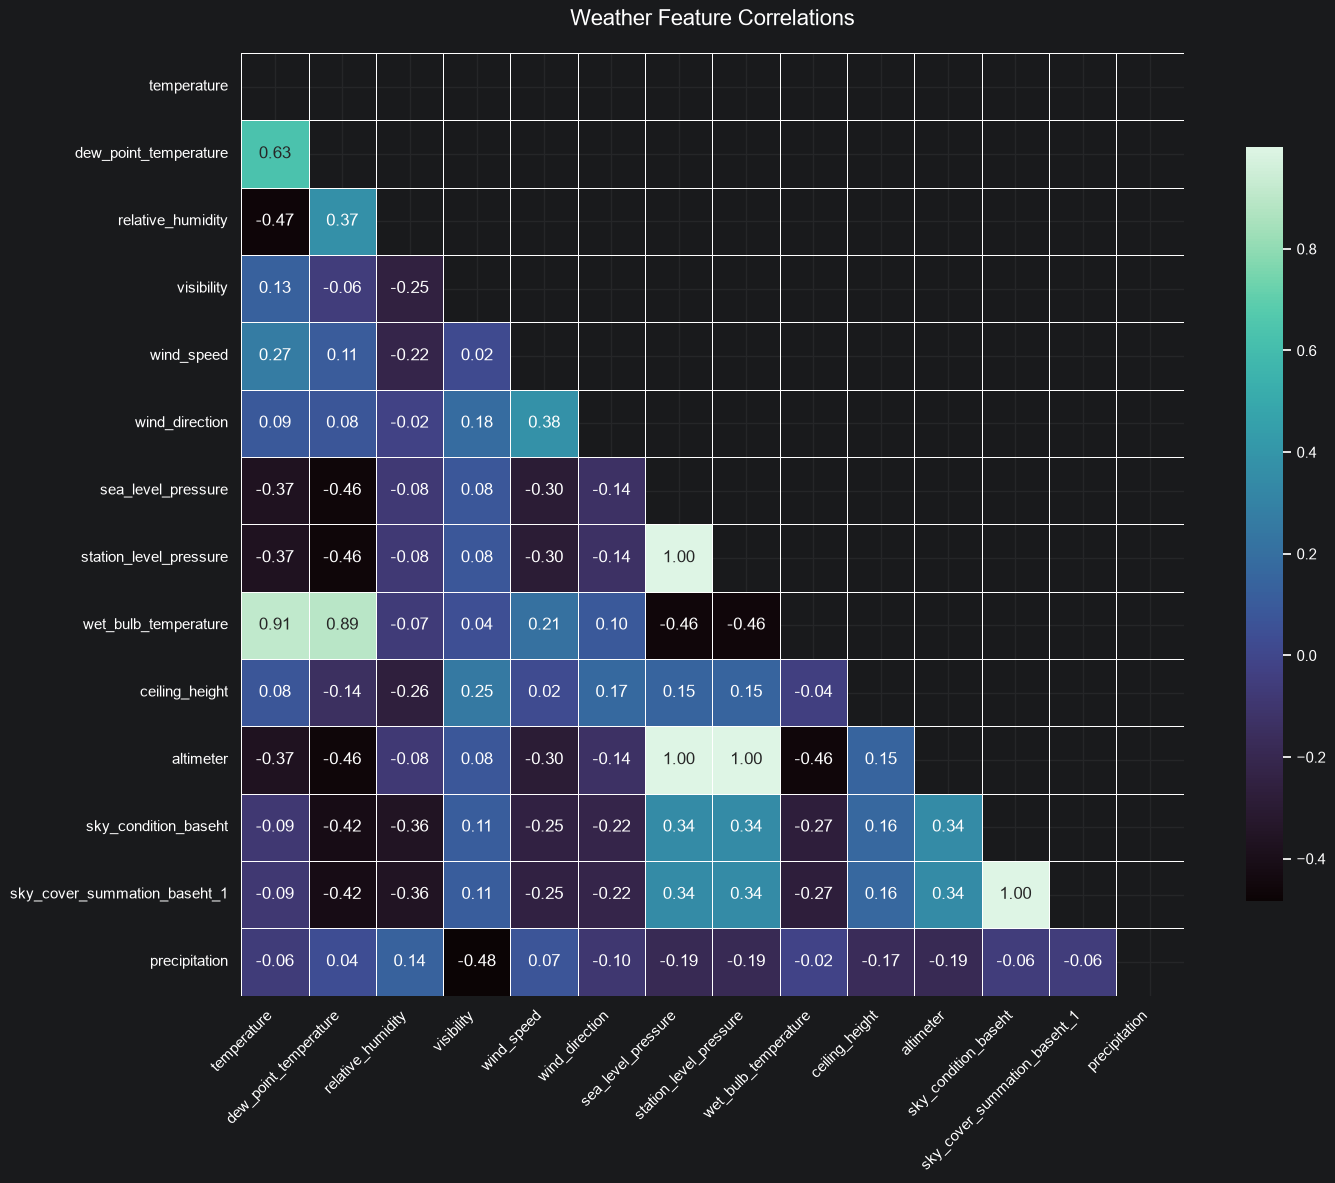

In [26]:
correlation_input = weather_train_df[weather_feature_columns].copy()
correlation_matrix = correlation_input.corr(method="pearson")

mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

plt.figure(figsize=(15, 12))

sns.heatmap(
    correlation_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="mako",
    linewidths=0.5,
    square=True,
    cbar_kws={"shrink": 0.8},
)

plt.xticks(rotation=45, ha="right")
plt.title("Weather Feature Correlations", fontsize=16, pad=20)
plt.tight_layout()
plt.show()

Comments: From the correlation matrix, the following features jump out as redundant:
1. altimeter, sea_level_pressure, station_level_pressure
2. sky_condition_baseht and sky_cover_summation_baseht_1
3. wet_bulb_temperature, temperature, dew_point_temperature

### Pairplot sample for different feature types

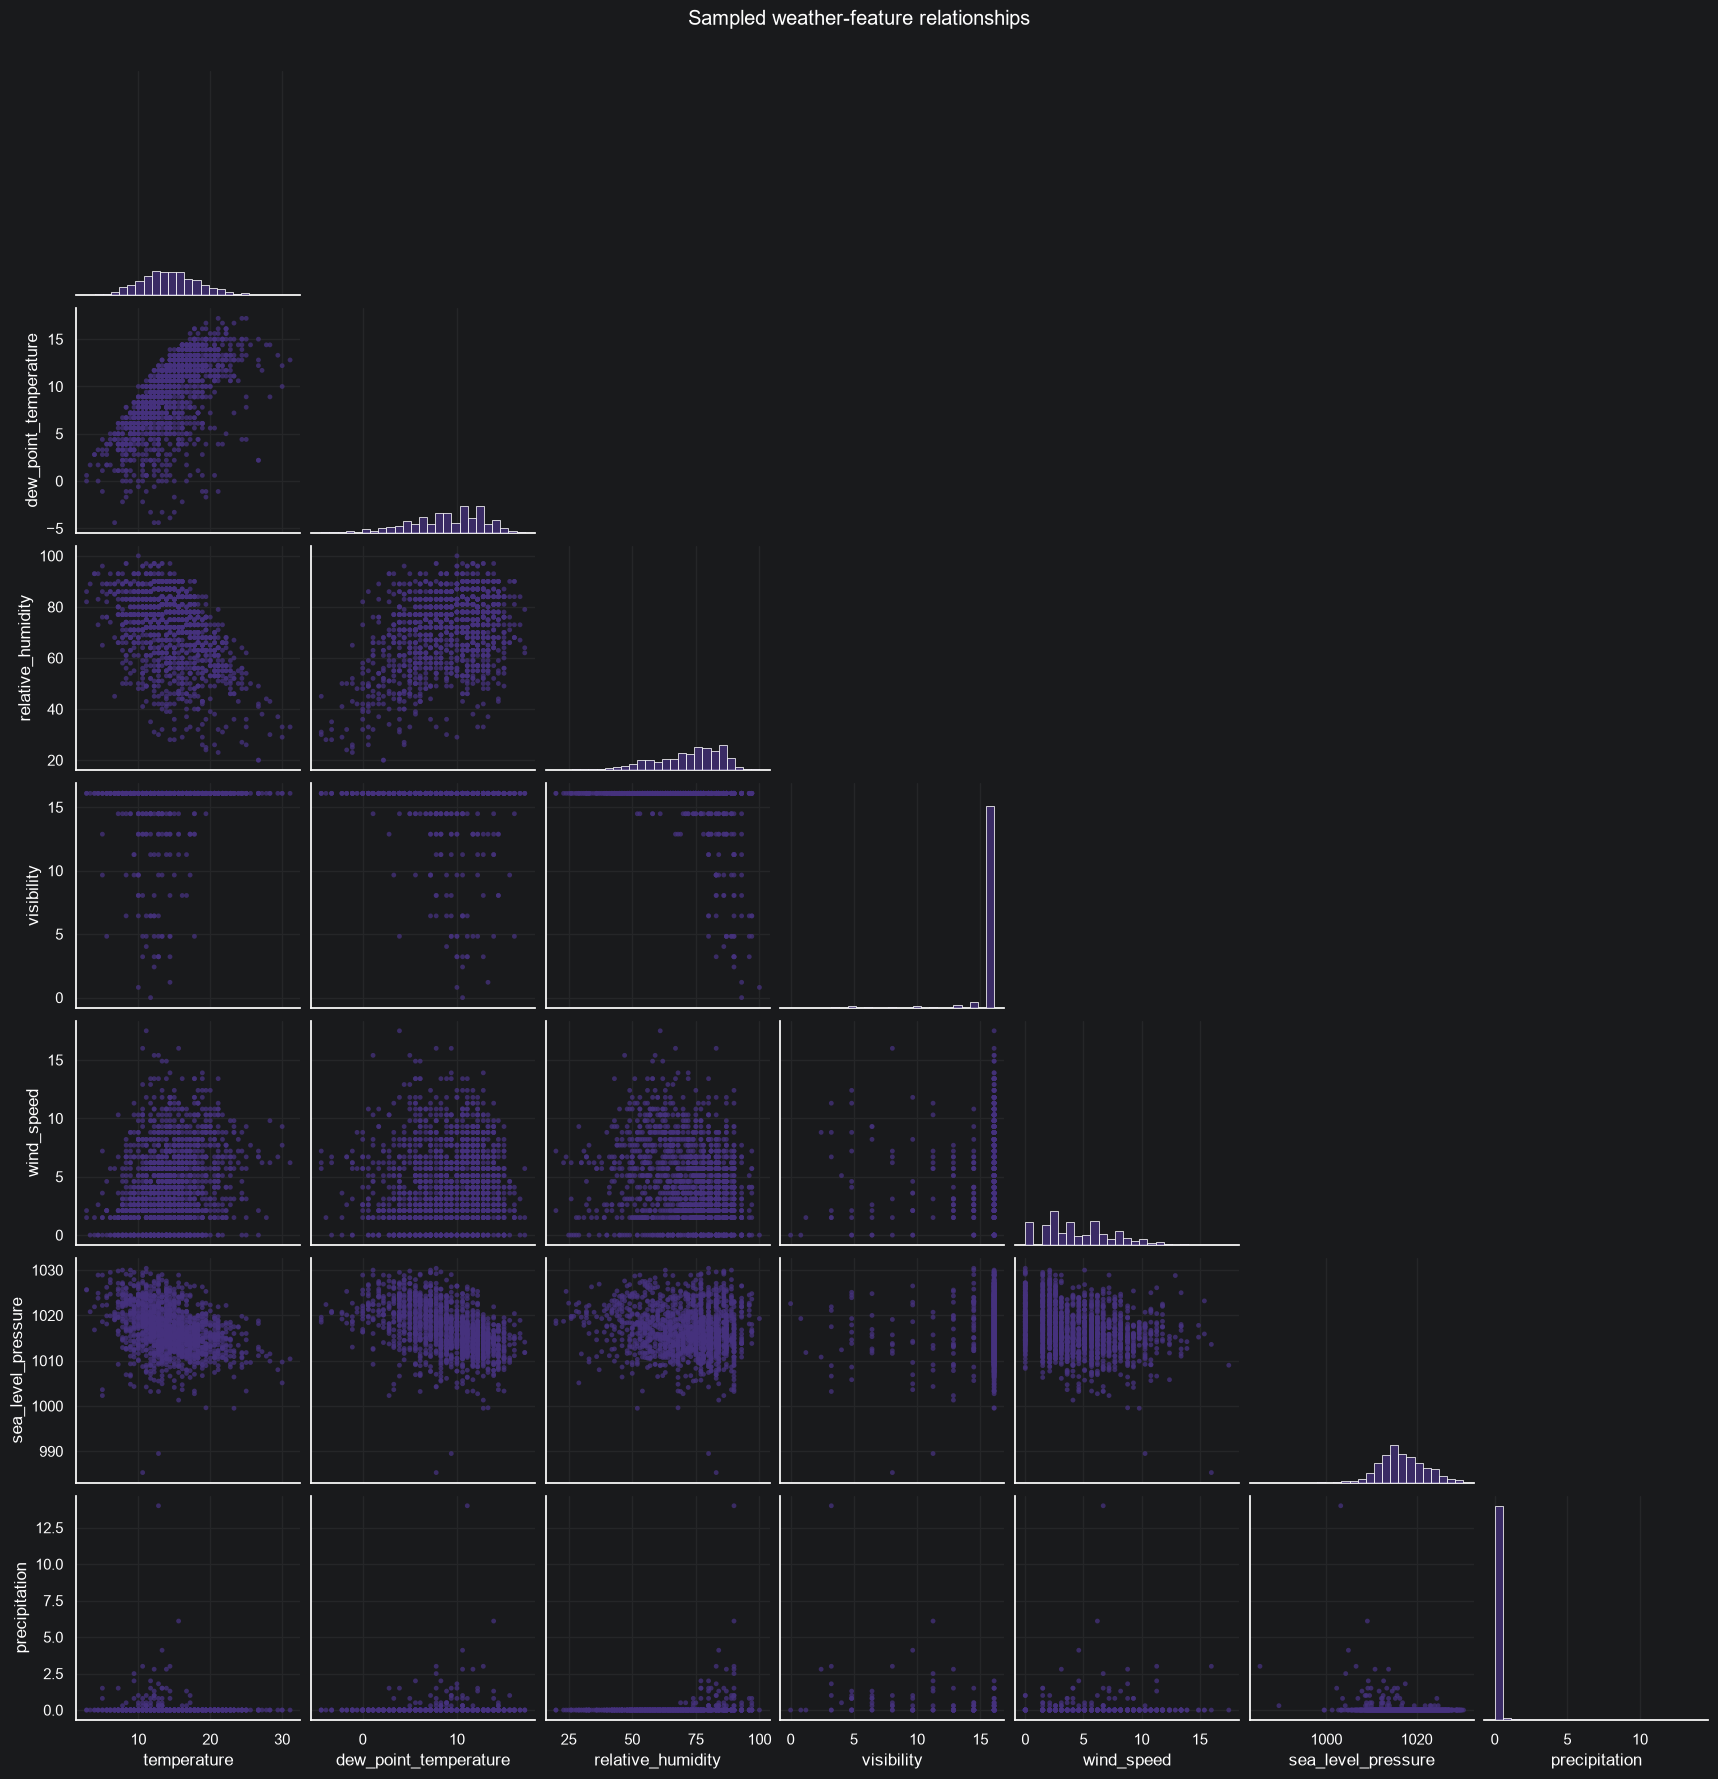

In [35]:
pairplot_columns = [
    "temperature",
    "dew_point_temperature",
    "relative_humidity",
    "visibility",
    "wind_speed",
    "sea_level_pressure",
    "precipitation",
]

pairplot_source = weather_train_df[pairplot_columns].dropna()
pairplot_sample = pairplot_source.sample(
    n=min(1500, len(pairplot_source)),
    random_state=RANDOM_STATE,
)

sns.pairplot(
    pairplot_sample,
    corner=True,
    diag_kind="hist",
    plot_kws={"alpha": 0.75, "s": 12, "edgecolor": "none"},
    diag_kws={"bins": 25},
)
plt.suptitle("Sampled weather-feature relationships", y=1.02)
plt.show()

### Final Comments

